Generating 100 samples of 2D inviscid Burgers ...
Processing sample 10/100...
Processing sample 20/100...
Processing sample 30/100...
Processing sample 40/100...
Processing sample 50/100...
Processing sample 60/100...
Processing sample 70/100...
Processing sample 80/100...
Processing sample 90/100...
Processing sample 100/100...

Generation complete.
x shape: (100, 100, 100)
y shape: (100, 51, 100, 100)


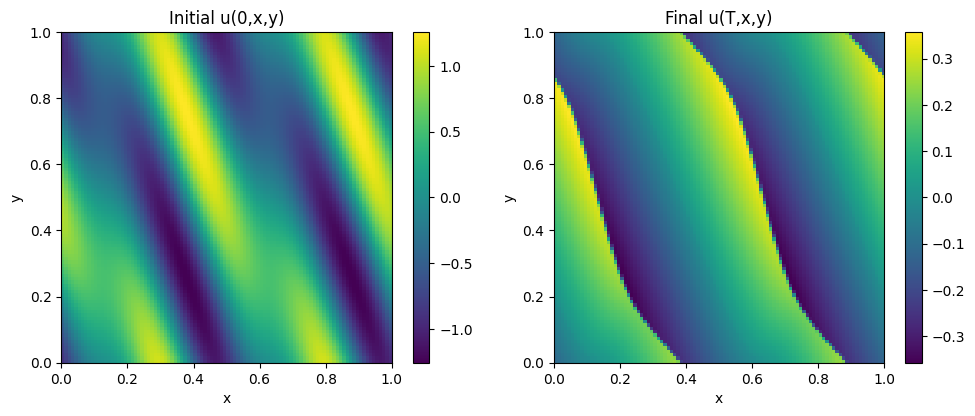

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 2D Inviscid Burgers (periodic): u_t + (u^2/2)_x + (u^2/2)_y = 0
# Full time series output: (Nt, Nx, Ny)
# ------------------------------------------------------------

def sample_ic_sinusoidal_2d(Nx, Ny, kmax=4, amp=1.0, rng=None):
    """
    v(x,y) = a sin(2π(mx+ny)) + b cos(2π(px+qy)), periodic on [0,1)^2
    Returns v shape (Nx, Ny)
    """
    if rng is None:
        rng = np.random.default_rng()

    x = np.linspace(0, 1, Nx, endpoint=False)
    y = np.linspace(0, 1, Ny, endpoint=False)
    X, Y = np.meshgrid(x, y, indexing="ij")  # (Nx, Ny)

    a = rng.uniform(-amp, amp)
    b = rng.uniform(-amp, amp)
    m = rng.integers(1, kmax + 1)
    n = rng.integers(1, kmax + 1)
    p = rng.integers(1, kmax + 1)
    q = rng.integers(1, kmax + 1)

    v = a * np.sin(2*np.pi*(m*X + n*Y)) + b * np.cos(2*np.pi*(p*X + q*Y))
    return v.astype(np.float32)


def burgers2d_step_rusanov(u, dt, dx, dy):
    """
    One Rusanov (local LF) step for:
      u_t + (u^2/2)_x + (u^2/2)_y = 0
    Periodic BCs via np.roll.
    u shape (Nx, Ny)
    """
    # x-direction numerical flux at i+1/2
    uR = np.roll(u, -1, axis=0)
    uL = u
    a = np.maximum(np.abs(uL), np.abs(uR))  # wave speed |df/du| = |u|
    Fx = 0.5*(0.5*uL**2 + 0.5*uR**2) - 0.5*a*(uR - uL)
    Fx_minus = np.roll(Fx, 1, axis=0)

    # y-direction numerical flux at j+1/2
    uU = np.roll(u, -1, axis=1)
    uD = u
    aY = np.maximum(np.abs(uD), np.abs(uU))
    Gy = 0.5*(0.5*uD**2 + 0.5*uU**2) - 0.5*aY*(uU - uD)
    Gy_minus = np.roll(Gy, 1, axis=1)

    # Conservative update
    u_new = u - (dt/dx)*(Fx - Fx_minus) - (dt/dy)*(Gy - Gy_minus)
    return u_new.astype(np.float32)


def solve_burgers2d_timeseries(u0, t_max=0.5, Nt=101, cfl=0.4, plot=False):
    u = u0.astype(np.float32).copy()
    Nx, Ny = u.shape
    dx = 1.0 / Nx
    dy = 1.0 / Ny

    # times = np.linspace(0.0, t_max, Nt, dtype=np.float32)
    times = np.linspace(0.0, t_max, Nt)  # float64

    u_series = np.empty((Nt, Nx, Ny), dtype=np.float32)
    u_series[0] = u

    t = 0.0
    k = 1

    steps = 0
    max_steps = 5_000_000


    while k < Nt:
        steps += 1
        if steps > max_steps:
            raise RuntimeError("Too many steps (possible CFL too small or NaN issue).")
    
        if not np.isfinite(u).all():
            raise RuntimeError("u became NaN/Inf, solver unstable.")
    
        umax = float(np.max(np.abs(u)))
        dt_cfl = cfl * min(dx, dy) / max(umax, 1e-6)
    
        dt_target = float(times[k] - t)
    
        # --- SNAP FIX ---
        if dt_target <= 1e-12:
            t = float(times[k])
            u_series[k] = u
            k += 1
            continue
    
        dt = min(dt_cfl, dt_target)
    
        if not np.isfinite(dt) or dt <= 0:
            raise RuntimeError(f"Bad dt={dt}, umax={umax}, t={t}, target={times[k]}")
    
        u = burgers2d_step_rusanov(u, dt, dx, dy)
        t += dt
    
        if t >= float(times[k]) - 1e-12:
            u_series[k] = u
            k += 1
    
    # safety
    u_series[-1] = u

    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        im0 = ax[0].imshow(u_series[0], origin="lower", aspect="auto")
        ax[0].set_title("Initial u(0,x,y)")
        plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

        im1 = ax[1].imshow(u_series[-1], origin="lower", aspect="auto")
        ax[1].set_title(f"Final u({t_max},x,y)")
        plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    return u_series



def create_burgers2d_dataset(N_SAMPLES=200, Nx=64, Ny=64, Nt=101,
                            X_MUL=1, T_MUL=1, t_max=0.5,
                            kmax=4, amp=1.0, seed=0, cfl=0.4):
    """
    Creates:
      x_data: (N, Nx, Ny)          initial conditions v(x,y)
      y_data: (N, Nt, Nx, Ny)      time series u(t,x,y)

    Uses X_MUL and T_MUL similarly to your advection code:
      - solve at (Nx*X_MUL, Ny*X_MUL) and ( (Nt-1)*T_MUL + 1 ) time steps
      - then downsample back to (Nx, Ny, Nt)
    """
    print(f"Generating {N_SAMPLES} samples of 2D inviscid Burgers ...")
    rng = np.random.default_rng(seed)

    Nx_hi = Nx * X_MUL
    Ny_hi = Ny * X_MUL
    Nt_hi = (Nt - 1) * T_MUL + 1

    x_data = np.zeros((N_SAMPLES, Nx, Ny), dtype=np.float32)
    y_data = np.zeros((N_SAMPLES, Nt, Nx, Ny), dtype=np.float32)

    for i in range(N_SAMPLES):
        every = max(1, N_SAMPLES // 10)   # prints ~10 times
        if (i + 1) % every == 0:
            print(f"Processing sample {i+1}/{N_SAMPLES}...", flush=True)

        # 1) IC at high-res
        u0_hi = sample_ic_sinusoidal_2d(Nx_hi, Ny_hi, kmax=kmax, amp=amp, rng=rng)

        # 2) Solve at high-res, full time series
        u_hi = solve_burgers2d_timeseries(u0_hi, t_max=t_max, Nt=Nt_hi, cfl=cfl, plot=False)  # (Nt_hi, Nx_hi, Ny_hi)

        # 3) Downsample
        x_data[i] = u0_hi[::X_MUL, ::X_MUL]                    # (Nx, Ny)
        y_data[i] = u_hi[::T_MUL, ::X_MUL, ::X_MUL]            # (Nt, Nx, Ny)

    data = {"x": x_data, "y": y_data}
    print("\nGeneration complete.")
    print("x shape:", data["x"].shape)  # (N, Nx, Ny)
    print("y shape:", data["y"].shape)  # (N, Nt, Nx, Ny)
    return data


# --- Example Usage / quick sanity plot ---
if __name__ == "__main__":
    data_dict = create_burgers2d_dataset(
        N_SAMPLES=100, Nx=100, Ny=100, Nt=51, X_MUL=2, T_MUL=10, t_max=0.5,
        kmax=4, amp=1.0, seed=123, cfl=0.4
    )

    sample_idx = 0
    u_series = data_dict["y"][sample_idx]  # (Nt, Nx, Ny)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(u_series[0].T, origin="lower", extent=[0,1,0,1], aspect="equal")
    plt.title("Initial u(0,x,y)")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar()
    
    plt.subplot(1,2,2)
    plt.imshow(u_series[-1].T, origin="lower", extent=[0,1,0,1], aspect="equal")
    plt.title("Final u(T,x,y)")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar()
    
    plt.tight_layout()
    plt.show()



<h2>Generate new 

<h2>Test</h2>

In [1]:
# Load the training mat
import scipy 

data_dict = scipy.io.loadmat("/home/tp526/Characteristics/data/test_data/burgers_2d_test_xy100_t51_500.mat")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


/home/tp526/neuraloperator/PI-FNO-reproduce
device: cuda
Loaded checkpoint: /home/tp526/neuraloperator/PI-FNO-reproduce/checkpoints/burgers2d-PINO/burgers2d_inviscid_4_64_mode_8_physics.pt
Plotting snapshots for sample 0 ...


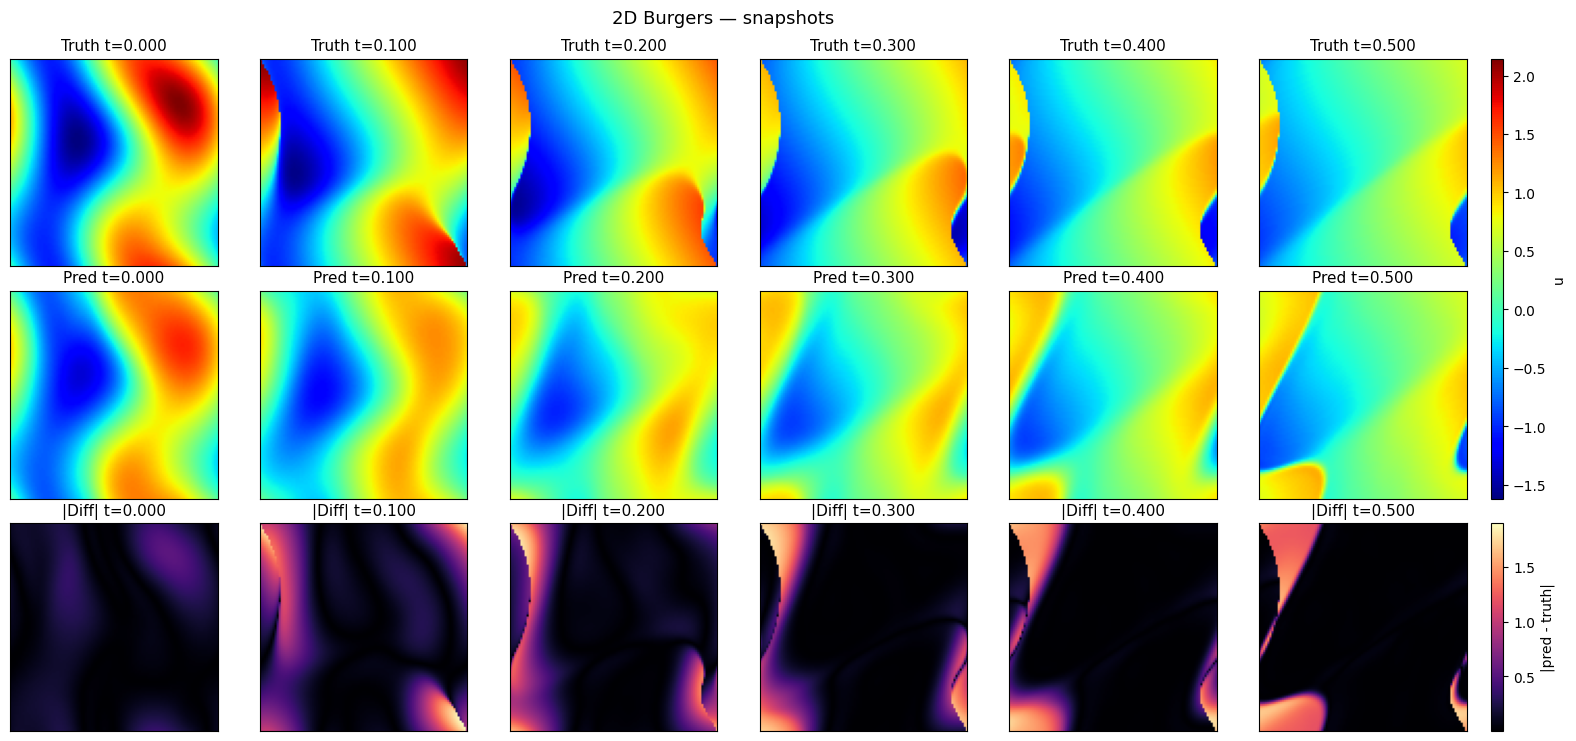


=== Summary over N_TEST = 500 ===
Mean rel L1 (space on snapshots): [0.11473288 0.30581698 0.33718577 0.38780215 0.5044293  0.64188904]   All: [0.12688261 0.32657894 0.3011264  0.29325882 0.33007762 0.3698837 ]
Mean rel L1 (space-time): 0.3906143307685852   Std: 0.12416267395019531


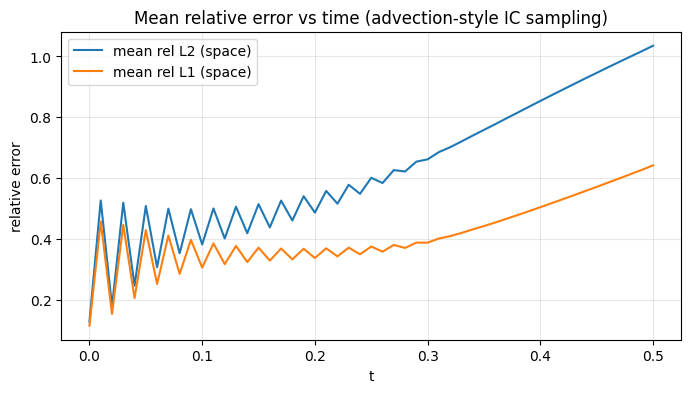

In [2]:
# =========================
# Burgers2D PINO Evaluation (advection-style: new ICs each run) 
# =========================
import os, yaml, numpy as np, torch
import matplotlib.pyplot as plt
#from models import FNO3d  # make sure this import works in your repo

import torch
import deepxde as dde

import torch.nn.functional as F

%cd ..
from models import FNO2d, FNO3d
from train_utils.datasets import MatReader, AdvectionLoader, Burgers2DLoader

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# ----------- USER: set these 2 paths -----------
CONFIG_PATH = "/home/tp526/neuraloperator/PI-FNO-reproduce/configs/pretrain/burgers2d_inviscid_pretrain_data.yaml"   # change
CKPT_PATH   = "/home/tp526/neuraloperator/PI-FNO-reproduce/checkpoints/burgers2d-PINO/burgers2d_inviscid_4_64_mode_8_physics.pt"      # change

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ---------- load config ----------
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

dcfg = config["data"]
mcfg = config["model"]

Nx = int(dcfg["nx"])
Ny = int(dcfg.get("ny", dcfg["nx"]))
Nt = int(dcfg["nt"])
t_max = float(dcfg["time_interval"])

assert Nx == Ny, "This evaluation cell assumes square grid (nx==ny)."

# ---------- build model ----------
model = FNO3d(
    modes1=[8, 4, 4],#[8, 8, 4, 4], #[8, 4, 4], #[16, 16, 12, 12], #mcfg["modes1"],
    modes2=[8, 4, 4], #[8, 8, 4, 4], #[8, 4, 4], #[16, 16, 12, 12], #mcfg["modes2"],
    modes3=[8, 4, 4], #[8, 8, 4, 4], # #[12, 8, 8, 6], #mcfg["modes3"],
    fc_dim=100, #128, #100, #mcfg["fc_dim"],
    layers=[64, 64, 64, 64]#[64, 64, 64] #[64, 64, 64, 64, 64] #mcfg["layers"],
).to(device)

# ---------- load checkpoint (save_checkpoint format) ----------
ckpt = torch.load(CKPT_PATH, map_location=device)
state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt

# handle DDP "module." prefix if present
if isinstance(state, dict) and any(k.startswith("module.") for k in state.keys()):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}

model.load_state_dict(state, strict=True)
model.eval()
print("Loaded checkpoint:", CKPT_PATH)

# ---------- helpers ----------
def build_fno3d_input_from_u0(u0_batch, T, t_interval, device):
    """
    u0_batch: torch (B,S,S)
    return:   torch (B,S,S,T,4) = [x,y,t,u0]
    """
    B, S, _ = u0_batch.shape
    x = torch.linspace(0, 1, S+1, device=device)[:-1]
    y = torch.linspace(0, 1, S+1, device=device)[:-1]
    t = torch.linspace(0, t_interval, T, device=device)

    gridx = x.view(1, S, 1, 1, 1).repeat(B, 1, S, T, 1)
    gridy = y.view(1, 1, S, 1, 1).repeat(B, S, 1, T, 1)
    gridt = t.view(1, 1, 1, T, 1).repeat(B, S, S, 1, 1)
    u0rep = u0_batch.view(B, S, S, 1, 1).repeat(1, 1, 1, T, 1)

    a = torch.cat([gridx, gridy, gridt, u0rep], dim=-1)  # (B,S,S,T,4)
    return a

def rel_l2(a, b, eps=1e-12):
    return np.linalg.norm(a-b) / (np.linalg.norm(b) + eps)

def rel_l1(a, b, eps=1e-12):
    return np.sum(np.abs(a-b)) / (np.sum(np.abs(b)) + eps)

import matplotlib.gridspec as gridspec

def plot_snapshots(truth, pred, t_indices, t_list, title_prefix="2D Burgers — snapshots"):
    """
    truth/pred: (S,S,T)
    t_grid: (T,)
    3 rows: Truth / Pred / |Pred-Truth|
    Dedicated right column for colorbars (no overlap).
    We plot .T to match your convention (x horizontal, y vertical).
    """
    S, _, T = truth.shape

    def t_to_idx(t):
        return int(np.argmin(np.abs(t_grid - t)))

    idxs = t_indices #[t_to_idx(t) for t in t_list]
    ncol = len(idxs)

    # Shared color scale for Truth+Pred
    vmin = float(min(truth[:, :, idxs].min(), pred[:, :, idxs].min()))
    vmax = float(max(truth[:, :, idxs].max(), pred[:, :, idxs].max()))

    # Shared color scale for |diff|
    err_stack = np.abs(pred[:, :, idxs] - truth[:, :, idxs])
    emin, emax = float(err_stack.min()), float(err_stack.max())

    # Layout: last column reserved for colorbars
    fig = plt.figure(figsize=(3.05*ncol + 1.2, 8.2))
    gs = gridspec.GridSpec(
        3, ncol + 1,
        width_ratios=[1]*ncol + [0.05],
        wspace=0.03, hspace=0.12
    )

    axes = np.empty((3, ncol), dtype=object)
    for i in range(3):
        for j in range(ncol):
            axes[i, j] = fig.add_subplot(gs[i, j])

    cax_main = fig.add_subplot(gs[0:2, -1])  # spans rows 0-1
    cax_err  = fig.add_subplot(gs[2, -1])    # row 2 only

    im_main = None
    im_err  = None

    for j, k in enumerate(idxs):
        im0 = axes[0, j].imshow(
            truth[:, :, k].T, origin="lower", extent=[0, 1, 0, 1],
            aspect="equal", vmin=vmin, vmax=vmax, cmap="jet"
        )
        axes[0, j].set_title(f"Truth t={t_grid[k]:.3f}", fontsize=11)
        axes[0, j].set_xticks([]); axes[0, j].set_yticks([])

        im1 = axes[1, j].imshow(
            pred[:, :, k].T, origin="lower", extent=[0, 1, 0, 1],
            aspect="equal", vmin=vmin, vmax=vmax, cmap="jet"
        )
        axes[1, j].set_title(f"Pred t={t_grid[k]:.3f}", fontsize=11)
        axes[1, j].set_xticks([]); axes[1, j].set_yticks([])

        err = np.abs(pred[:, :, k] - truth[:, :, k])
        im2 = axes[2, j].imshow(
            err.T, origin="lower", extent=[0, 1, 0, 1],
            aspect="equal", vmin=emin, vmax=emax, cmap="magma"
        )
        axes[2, j].set_title(f"|Diff| t={t_grid[k]:.3f}", fontsize=11)
        axes[2, j].set_xticks([]); axes[2, j].set_yticks([])

        if im_main is None: im_main = im0
        if im_err  is None: im_err  = im2

    cb1 = fig.colorbar(im_main, cax=cax_main)
    cb1.set_label("u", rotation=90)

    cb2 = fig.colorbar(im_err, cax=cax_err)
    cb2.set_label("|pred - truth|", rotation=90)

    fig.suptitle(title_prefix, y=0.99, fontsize=13)
    fig.subplots_adjust(top=0.93)
    plt.show()


# ---------- evaluation settings ----------
N_TEST = 500         # increase for more stable metrics (but truth gen is slow)
EVAL_SEED = None      # set None for different ICs each run (metrics will vary)
kmax = 4
amp = 1.0
cfl = 0.4

rn = np.random.randint(N_TEST)

rng = np.random.default_rng(EVAL_SEED) if EVAL_SEED is not None else np.random.default_rng()

t_grid = np.linspace(0.0, t_max, Nt)  # float64 (consistent with your solver)
t_indices = [0, 10, 20, 30, 40, 50]
t_list = [0.0, 0.2*t_max, 0.4*t_max, 0.6*t_max, 0.8*t_max, t_max]

l2_all, l1_all = [], []
l2_time, l1_time = [], []
l1_time_err = []

# ---------- main loop ----------
with torch.no_grad():
    for i in range(N_TEST):
        # # 1) sample IC
        # u0 = sample_ic_sinusoidal_2d(Nx, Ny, kmax=kmax, amp=amp, rng=rng)  # (Nx,Ny) float32
        u0 = data_dict['input'][i].astype(np.float32)

        # # 2) ground truth (Nt,Nx,Ny)
        # u_series = solve_burgers2d_timeseries(u0, t_max=t_max, Nt=Nt, cfl=cfl, plot=False)
        u_series = data_dict['output'][i].astype(np.float32)

        # convert truth to (S,S,T) = (Nx,Ny,Nt)
        truth = np.transpose(u_series, (1, 2, 0)).astype(np.float32)

        # 3) model input
        u0_torch = torch.from_numpy(u0).to(device)                 # (S,S)
        u0_batch = u0_torch.unsqueeze(0)                           # (1,S,S)
        x_in = build_fno3d_input_from_u0(u0_batch, Nt, t_max, device)  # (1,S,S,T,4)

        # ?? to be consistant with the training #
        x_in = F.pad(x_in, (0, 0, 0, 5), "constant", 0)
        
        ###################################
        # print("Check bug")
        # print("Time 0")
        # v_in = x_in[0, :, :, 0, -1]
        # plt.imshow(v_in.detach().cpu().numpy(), cmap="jet", origin="lower")
        # plt.colorbar() 
        # plt.show()

        # print("Time 0.5")
        # v_in = x_in[0, :, :, -6, -1]
        # plt.imshow(v_in.detach().cpu().numpy(), cmap="jet", origin="lower")
        # plt.colorbar() 
        # plt.show()
        ####################################

        # 4) predict
        out = model(x_in).reshape(1, 100, 100, Nt + 5)[:, :, :, :-5]
        # match expected output shape (1,S,S,T)
        pred = out[0].reshape(Nx, Ny, Nt).detach().cpu().numpy().astype(np.float32)

        # 5) errors (overall space-time)
        l2_all.append(rel_l2(pred.ravel(), truth.ravel()))
        l1_all.append(rel_l1(pred.ravel(), truth.ravel()))

        # 6) errors vs time (space only)
        l2_t = [rel_l2(pred[:, :, k].ravel(), truth[:, :, k].ravel()) for k in range(Nt)]
        l1_t = [rel_l1(pred[:, :, k].ravel(), truth[:, :, k].ravel()) for k in range(Nt)]
        l2_time.append(l2_t)
        l1_time.append(l1_t)

        l1_t_err = [np.mean(np.abs(pred[:, :, k].ravel() - truth[:, :, k].ravel())) for k in range(Nt)]
        l1_time_err.append(l1_t_err)

        # 7) plot snapshots for the first sample
        if i == rn:
            print("Plotting snapshots for sample 0 ...")
            plot_snapshots(
                truth, pred,
                t_indices=t_indices,#t_grid=t_grid,
                t_list=t_list,
                title_prefix="2D Burgers — snapshots"
            )


l2_all = np.array(l2_all)
l1_all = np.array(l1_all)
l2_time = np.array(l2_time)  # (N_TEST,Nt)
l1_time = np.array(l1_time)

l1_time_err = np.array(l1_time_err)

print("\n=== Summary over N_TEST =", N_TEST, "===")
print("Mean rel L1 (space on snapshots):", l1_time.mean(axis=0)[::10], "  All:", l1_time_err.mean(axis=0)[::10])
print("Mean rel L1 (space-time):", float(l1_all.mean()), "  Std:", float(l1_all.std()))

plt.figure(figsize=(8,4))
plt.plot(t_grid, l2_time.mean(axis=0), label="mean rel L2 (space)")
plt.plot(t_grid, l1_time.mean(axis=0), label="mean rel L1 (space)")
plt.xlabel("t"); plt.ylabel("relative error")
plt.title("Mean relative error vs time (advection-style IC sampling)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:
print("-" * 100)
print("\nNumber of trainable parameters: ", sum(p.numel() for p in model.parameters())
print("\n" + "-" * 100)

----------------------------------------------------------------------------------------------------

Number of trainable parameters:  4600385

----------------------------------------------------------------------------------------------------


In [3]:
l1_time.shape

(500, 51)

In [4]:
# Save error
np.save("/home/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_2d_post_fno_relative_l1.npy", l1_time[:, ::5].astype(np.float32))

Text(0.5, 1.0, 'L1 Relative Errors 500 Initial Conditions')

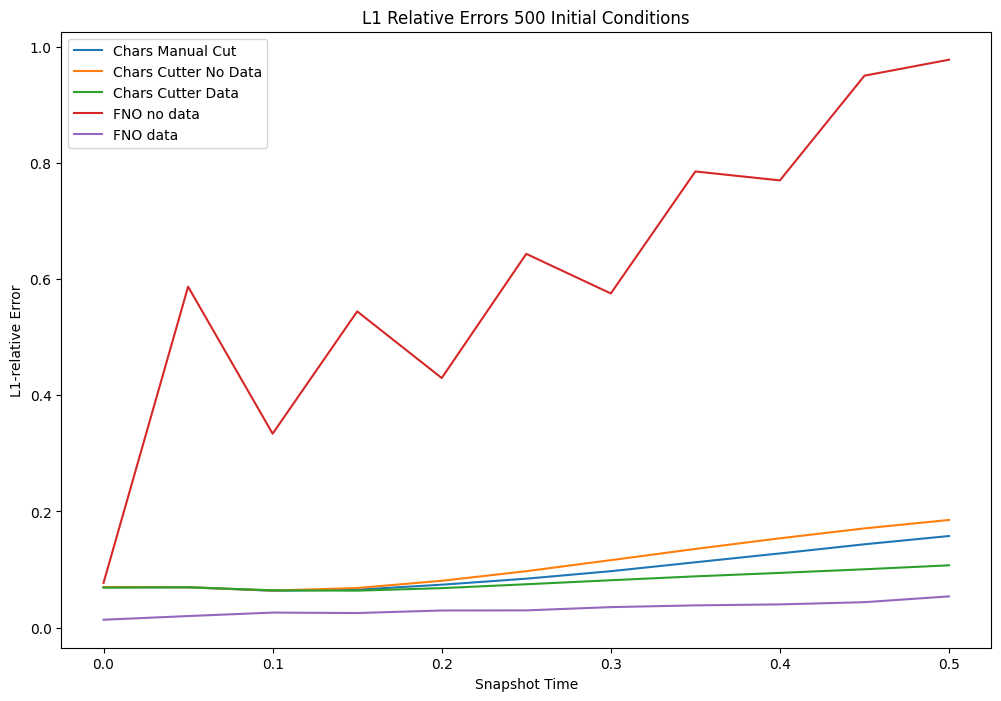

In [9]:
l1_manual = np.load("/home/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_2d_post_manual_relative_l1.npy")
l1_cutter_no_data = np.load("/home/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_2d_post_no_data_cutter_relative_l1.npy")
l1_cutter_data = np.load("/home/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_2d_post_data_relative_l1.npy")
l1_fno_no_data = np.load("/home/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_2d_post_fno_relative_l1.npy")

l1_fno_data = np.array([0.0136, 0.0199, 0.0259, 0.0251, 0.0295, 0.0297, 0.0353, 0.0383, 0.0400, 0.0438, 0.0538])


plt.figure(figsize=(12, 8))
x = np.linspace(0, 0.5, 11)
plt.plot(x, l1_manual.mean(axis=0), label="Chars Manual Cut")
plt.plot(x, l1_cutter_no_data.mean(axis=0), label="Chars Cutter No Data")
plt.plot(x, l1_cutter_data.mean(axis=0), label="Chars Cutter Data")
plt.plot(x, l1_fno_no_data.mean(axis=0), label="FNO no data")
plt.plot(x, l1_fno_data, label="FNO data")
plt.xlabel("Snapshot Time")
plt.ylabel("L1-relative Error")
plt.legend()
plt.title("L1 Relative Errors 500 Initial Conditions")